In [2]:
#=============================================================================================================================
# CREDIT SCORING - MODÉLISATION
#==============================================================================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                            confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
import joblib

print ("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


In [3]:
processed_dir = os.path.join(os.path.expanduser('~'),
                             'credit_scoring_project',
                             'data', 'processed')

X = pd.read_csv(os.path.join(processed_dir, 'X_preprocessed.csv'))
y = pd.read_csv(os.path.join(processed_dir, 'y_preprocessed.csv')).squeeze()

print(f"✅Données chargées")
print(f"X : {X.shape}")
print(f"y : {y.shape}")
print(f"Taux de défaut : {y.mean()*100:.2f}%")

✅Données chargées
X : (307511, 181)
y : (307511,)
Taux de défaut : 8.07%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)
print(f"Train : {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"Taux de défaut train : {y_train.mean()*100:.2f}%")
print(f"Taux de défaut test : {y_test.mean()*100:.2f}%")

Train : (246008, 181)
Test : (61503, 181)
Taux de défaut train : 8.07%
Taux de défaut test : 8.07%


In [5]:
###ENTRAÎNEMENT DES MODÈLES

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='auc', n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"Entraînement : {name} ...")
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    print(f"  AUC-ROC : {auc:.4f}")

print("\n✅ Tous les modèles ont été entrainés")

Entraînement : Logistic Regression ...
  AUC-ROC : 0.7456
Entraînement : Decision Tree ...
  AUC-ROC : 0.5350
Entraînement : Random Forest ...
  AUC-ROC : 0.7104
Entraînement : Gradient Boosting ...
  AUC-ROC : 0.7496
Entraînement : XGBoost ...
  AUC-ROC : 0.7498

✅ Tous les modèles ont été entrainés


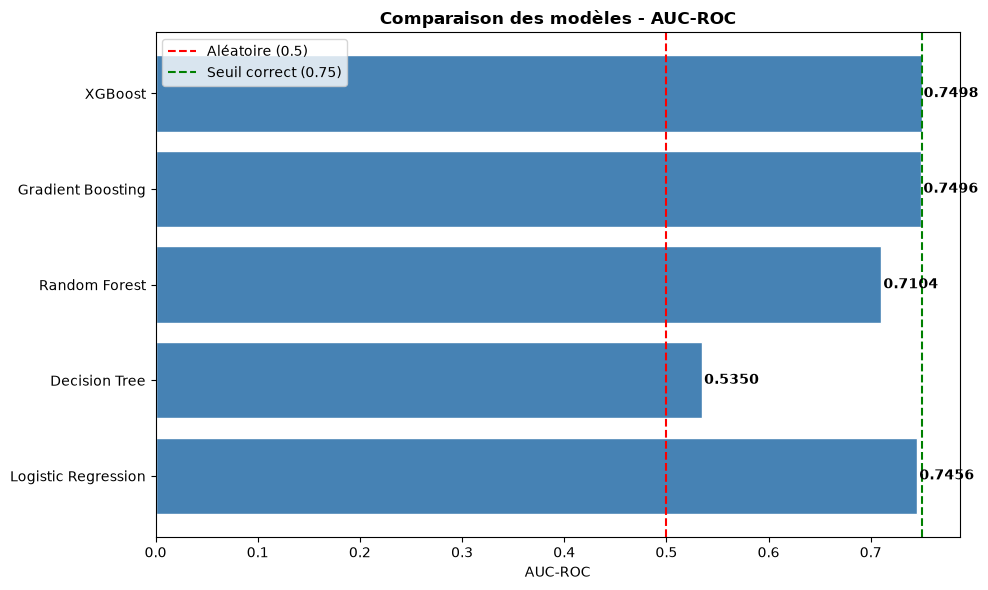

In [6]:
plt.figure(figsize=(10, 6))
models_names = list(results.keys())
auc_scores = list(results.values())
images_dir = os.path.join(os.path.expanduser('~'),
                          'credit_scoring_project','images')

bars = plt.barh(models_names, auc_scores, color='steelblue', edgecolor='white')
plt.axvline(x=0.5, color='red', linestyle='--', label='Aléatoire (0.5)')
plt.axvline(x=0.75, color='green', linestyle='--', label='Seuil correct (0.75)')
plt.xlabel('AUC-ROC')
plt.title('Comparaison des modèles - AUC-ROC', fontweight='bold')
plt.legend()

for bar, score in zip(bars, auc_scores):
    plt.text(score + 0.002, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(images_dir, '09_model_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 5, 10]
}

xgb =XGBClassifier(random_state=42, eval_metric='auc', n_jobs=-1)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres : {search.best_params_}")
print(f"Meilleur AUC-ROC : {search.best_score_:.4f}")
    

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Meilleurs paramètres : {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Meilleur AUC-ROC : 0.7500


In [10]:

best_model = search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

auc_final = roc_auc_score(y_test, y_pred_proba)
print(f"✅AUC-ROC final : {auc_final:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred))

✅AUC-ROC final : 0.7563

Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.18      0.63      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.56     61503
weighted avg       0.90      0.73      0.79     61503



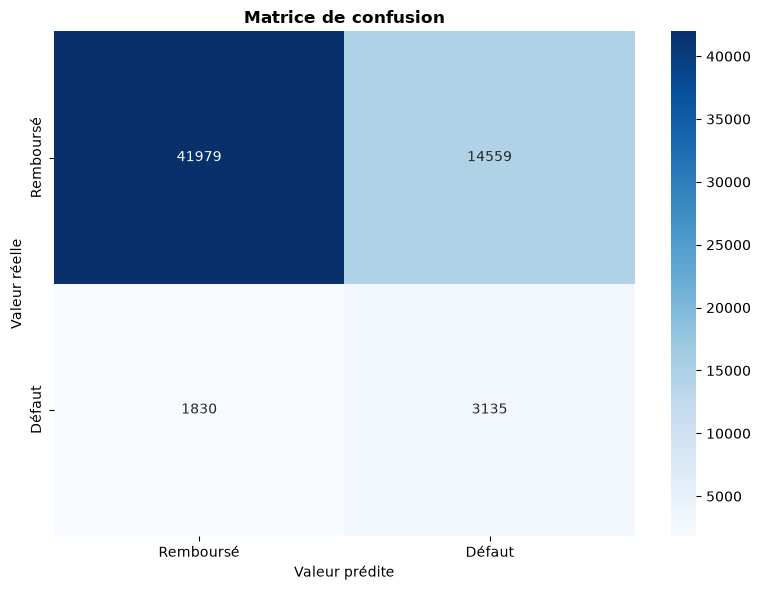

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Remboursé', 'Défaut'],
            yticklabels=['Remboursé', 'Défaut'])
plt.title('Matrice de confusion', fontweight='bold')
plt.ylabel('Valeur réelle')
plt.xlabel('Valeur prédite')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, '10_confusion_matrice.png'),
                        dpi=150, bbox_inches='tight')
plt.show()


In [13]:
models_dir = os.path.join(os.path.expanduser('~'),
                          'credit_scoring_project', 'models')

joblib.dump(best_model, os.path.join(models_dir, 'xgboost_final.pkl'))
print("✅Modèle sauvegardé")

✅Modèle sauvegardé
